# NON LINEAR REGRESSION MODELS

# Objective
This homework sheet will help reviewing the basic concepts associated with non-linear models. Please review the lectures, suggested readings, and additional resources _before_ getting started on the HW.

**Some questions in this assignment will require you to conduct independent research beyond the material covered in the recorded content.**

**Some of the libraries / links mentioned in APPLIED questions are only for your reference. Unless specifically indicated, feel free to utilise any Python library of your choice to carry out the assignment questions**

PYGAM REFERENCE LINK:

https://pygam.readthedocs.io/en/latest/notebooks/tour_of_pygam.html

STATSMODELS REFERENCE LINK:

https://www.statsmodels.org/dev/glm.html

PATSY REFERENCE LINK:

https://patsy.readthedocs.io/en/latest/







The following website has access to the relevant datasets from the recommended textbook: https://book.huihoo.com/introduction-to-statistical-learning/data.html


Marks Distribution

| Question      | Marks |
| ----------- | ----------- |
| 1a    |    0.5  |
| 1b    |    0.5   |
| 1c    |    0.5   |
| 1d     |   0.5    |
| 1e     |   0.5   |
| 2     |   1   |
| 3     |   1  |
| 4     |   1   |
| 5a    |   0.5   |
| 5b    |   0.5   |
| 5c    |   0.5  |
| 6a    |    2  |
| 6b    |   1    |
| 7a    |   1   |
| 7b    |   2   |
| 7c    |   1    |
| 7d   |    1   |





# Conceptual

## Question 1

Suppose that a curve $\hat{g}$ is computed to smoothly fit a set of `n` points using the following formula:

  $$
  \hat{g} = \arg\min_{g}(\sum_{i=1}^n (y_i - g(x_i))^2 +  \lambda \int [g^{(m)} (x)]^2 dx )
  $$
where $g^{(m)}$  represents the $m^{th}$ derivative of $g$ (and $g^{(0)} = g$. Provide a description (or sketch) of $\hat{g}$ in each of the following scenarios. where $g^{(m)}$
 represents the m
th derivative of g



  (a) $\lambda$ = $\infty$, $m = 0$.
  

  


**ANSWER**



### **Description of ( $\hat{g}(x)$\) for ( $\lambda \to \infty, m=0$ )**  

- The function $ \hat{g}(x) $ is a **constant function**, meaning it does not vary with $ x $.  
- Since **$ m = 0 $**, we are penalizing changes in $ g(x) $ itself, leading to the smoothest possible function, which is a horizontal line.  
- Because **$ \lambda \to \infty $**, the penalty for any deviation is infinitely large, forcing $ g(x) $ to remain constant across all $ x $.  
- Mathematically, the best constant approximation to the data is the **mean of the observed $ y $ values**:  

$$
\hat{g}(x) = \frac{1}{n} \sum_{i=1}^{n} y_i
$$  

Thus, $ \hat{g}(x) $ is a straight, **horizontal line at the mean of $ y $**.  

---

- Since ( $\lambda \to \infty$ ), the function is forced to be as smooth as possible. The only function with no variation at all is a constant function, which is why $\hat{g}(x)$  becomes the mean of \( y \).


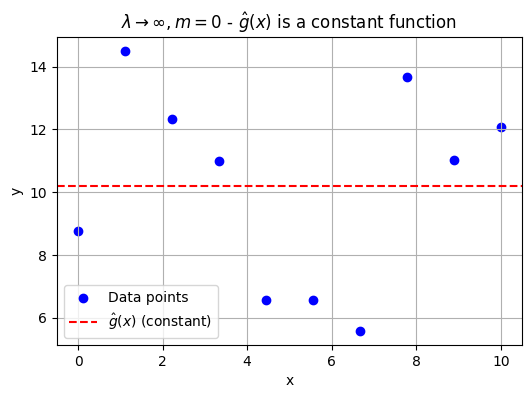

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate sample data points
np.random.seed(42)
x = np.linspace(0, 10, 10)
y = np.random.uniform(5, 15, size=len(x))

# Compute the mean of y (since g-hat is a constant function)
g_hat = np.mean(y)

# Create a plot
plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='blue', label='Data points')
plt.axhline(y=g_hat, color='red', linestyle='--', label=r'$\hat{g}(x)$ (constant)')
plt.xlabel('x')
plt.ylabel('y')
plt.title(r'$\lambda \to \infty, m=0$ - $\hat{g}(x)$ is a constant function')
plt.legend()
plt.grid(True)

# Display the plot
plt.show()


  (b) $\lambda$ = $\infty$, $m = 1$.
  



**ANSWER**


### **Description of ( $\hat{g}(x)$ ) for ( $\lambda \to \infty, m=1$ )**  

- The function $ \hat{g}(x) $ is a **linear function** because we are penalizing changes in its **first derivative**.  
- Since **$ m = 1 $**, we penalize changes in the slope of $ g(x) $, enforcing a function with minimal curvature.  
- Because **$ \lambda \to \infty $**, deviations from smoothness are highly penalized, forcing $ g(x) $ to be the simplest smooth function: a **straight line**.  
- This results in a **linear least squares regression**, where $ \hat{g}(x) $ takes the form:  

$$
\hat{g}(x) = a + bx
$$  

where $ a $ and $ b $ are determined by minimizing the squared error.  

Thus, $ \hat{g}(x) $ is a straight **best-fit line** to the data.


---

- Since ( $\lambda \to \infty$ ), the function is forced to be as smooth as possible, which means it must have a constant slope—resulting in a straight line.


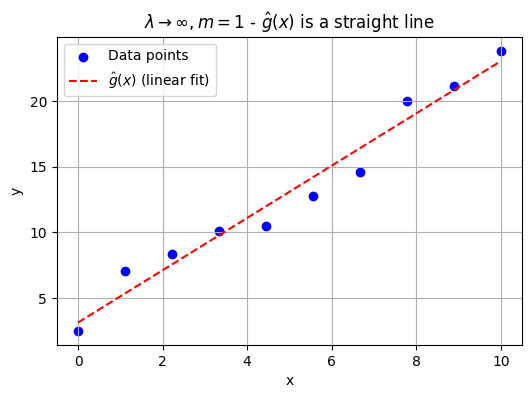

In [ ]:
# Generate sample data points for Q1(b)
np.random.seed(42)
x = np.linspace(0, 10, 10)
y = 3 + 2 * x + np.random.uniform(-2, 2, size=len(x))  # Simulating a linear trend with noise

# Fit a linear regression (since g-hat is a straight line)
coeffs = np.polyfit(x, y, 1)  # Fit a line (degree 1 polynomial)
g_hat_line = np.poly1d(coeffs)  # Get the function

# Create a plot
plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='blue', label='Data points')
plt.plot(x, g_hat_line(x), color='red', linestyle='--', label=r'$\hat{g}(x)$ (linear fit)')
plt.xlabel('x')
plt.ylabel('y')
plt.title(r'$\lambda \to \infty, m=1$ - $\hat{g}(x)$ is a straight line')
plt.legend()
plt.grid(True)

# Display the plot
plt.show()


  
  (c) $\lambda$ = $\infty$, $m = 2$.
  

  


**ANSWER**

### **Description of ( $\hat{g}(x)$ ) for ( $\lambda \to \infty, m=2$ )**  

- The function ( $\hat{g}(x)$ ) is a **quadratic function (parabola)** because we are penalizing changes in its **second derivative**.  
- Since **\( m = 2 \)**, we penalize variations in curvature, enforcing a function with minimal bending.  
- Because **( $\lambda \to \infty$ )**, deviations from smoothness are highly penalized, forcing  $g(x)$  to be the simplest smooth function that allows slight bending: a **parabola**.  
- This results in a **quadratic least squares regression**, where ( $\hat{g}(x)$ ) takes the form:  

$$
\hat{g}(x) = ax^2 + bx + c
$$  

where \( a, b, c \) are determined by minimizing the squared error.  

Thus, ( $\hat{g}(x)$) is a **smoothly curved parabola** best fitting the data.

---
- Since ( $\lambda \to \infty$ ), the function is forced to be as smooth as possible while allowing slight bending. The smoothest function that permits curvature but avoids sharp changes is a quadratic function.



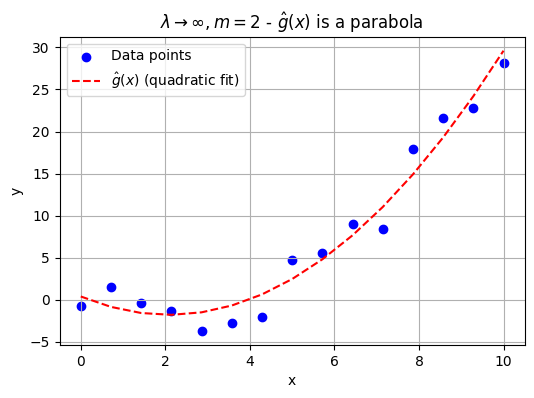

In [ ]:
# Generate sample data points for Q1(c)
np.random.seed(42)
x = np.linspace(0, 10, 15)
y = 0.5 * x**2 - 2 * x + np.random.uniform(-3, 3, size=len(x))  # Simulating a quadratic trend with noise

# Fit a quadratic regression (since g-hat is a parabola)
coeffs = np.polyfit(x, y, 2)  # Fit a 2nd degree polynomial (quadratic)
g_hat_quad = np.poly1d(coeffs)  # Get the function

# Create a plot
plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='blue', label='Data points')
plt.plot(x, g_hat_quad(x), color='red', linestyle='--', label=r'$\hat{g}(x)$ (quadratic fit)')
plt.xlabel('x')
plt.ylabel('y')
plt.title(r'$\lambda \to \infty, m=2$ - $\hat{g}(x)$ is a parabola')
plt.legend()
plt.grid(True)

# Display the plot
plt.show()


  (d) $\lambda$ = $\infty$, $m = 3$.
  


**ANSWER**

### **Description of ( $\hat{g}(x)$ ) for ( $\lambda \to \infty, m=3$ )**  

- The function ( $\hat{g}(x)$ ) is a **cubic function** because we are penalizing changes in its **third derivative**.  
- Since **\( m = 3 \)**, we penalize variations in how the curvature itself changes, enforcing a function with minimal fluctuations in bending rate.  
- Because **( $\lambda \to \infty$ )**, deviations from smoothness are highly penalized, forcing ( $g(x)$ ) to be the simplest smooth function that allows gradual bending: a **cubic polynomial**.  
- This results in a **cubic least squares regression**, where \( \hat{g}(x) \) takes the form:  

$$
\hat{g}(x) = ax^3 + bx^2 + cx + d
$$  

where \( a, b, c, d \) are determined by minimizing the squared error.  

Thus,  $\hat{g}(x)$  is a **smoothly curved cubic function** best fitting the data.

---

- Since ( $\lambda \to \infty$ ), the function is forced to be as smooth as possible while allowing gradual bending. The simplest function that permits smooth curvature with minimal fluctuations in bending rate is a cubic function.


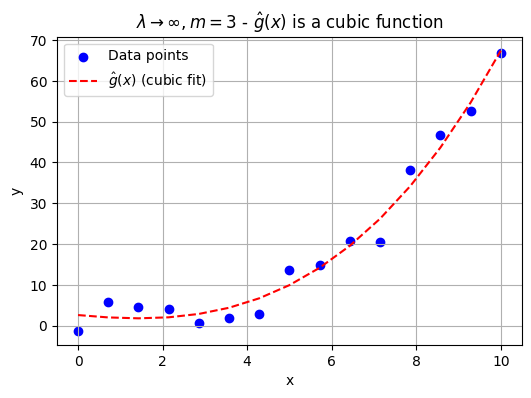

In [ ]:
# Generate sample data points for Q1(d)
np.random.seed(42)
x = np.linspace(0, 10, 15)
y = 0.1 * x**3 - 0.5 * x**2 + 2 * x + np.random.uniform(-5, 5, size=len(x))  # Simulating a cubic trend with noise

# Fit a cubic regression (since g-hat is a cubic function)
coeffs = np.polyfit(x, y, 3)  # Fit a 3rd degree polynomial (cubic)
g_hat_cubic = np.poly1d(coeffs)  # Get the function

# Create a plot
plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='blue', label='Data points')
plt.plot(x, g_hat_cubic(x), color='red', linestyle='--', label=r'$\hat{g}(x)$ (cubic fit)')
plt.xlabel('x')
plt.ylabel('y')
plt.title(r'$\lambda \to \infty, m=3$ - $\hat{g}(x)$ is a cubic function')
plt.legend()
plt.grid(True)

# Display the plot
plt.show()


  
  (e) $\lambda$ = 0, $m = 3$.

**ANSWER**

### **Description of \( $\hat{g}(x)$ \) for \( $\lambda = 0, m=3$ \)**  

- Since \( $\lambda = 0$ \), there is **no smoothing penalty**, allowing the function $ g(x) $ to fit the data freely.  
- With **\( m = 3 \)**, we would normally penalize the third derivative, but because ( $\lambda = 0$ ), this penalty is ignored.  
- As a result, ( $\hat{g}(x)$ ) becomes an **overfitted function**, capturing all variations in the data, including noise.  
- The function will be a **high-degree polynomial or a highly oscillatory spline** that interpolates the data points exactly.  
- Mathematically, this can be expressed as a **high-degree polynomial**:

$$
\hat{g}(x) = a_n x^n + a_{n-1} x^{n-1} + ... + a_1 x + a_0
$$  

where \( n \) is large enough to pass through most data points.

Thus, ( $\hat{g}(x)$ ) is a **highly fluctuating, overfit function**.

---

- Since ( $\lambda = 0$ ), there is no smoothing constraint, allowing the function to fully adapt to every data point. This leads to a highly fluctuating curve that captures noise, resulting in overfitting.



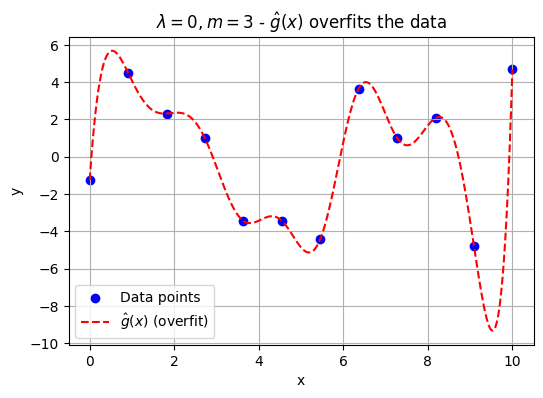

In [ ]:
from scipy.interpolate import make_interp_spline

# Generate sample data points for Q1(e)
np.random.seed(42)
x = np.linspace(0, 10, 12)
y = np.random.uniform(-5, 5, size=len(x))  # Random fluctuations to simulate noise

# Fit a high-degree polynomial spline (overfitting scenario)
x_smooth = np.linspace(x.min(), x.max(), 300)  # Smooth x values
spl = make_interp_spline(x, y, k=5)  # k=5 allows for a highly flexible fit
y_smooth = spl(x_smooth)

# Create a plot
plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='blue', label='Data points')
plt.plot(x_smooth, y_smooth, color='red', linestyle='--', label=r'$\hat{g}(x)$ (overfit)')
plt.xlabel('x')
plt.ylabel('y')
plt.title(r'$\lambda = 0, m=3$ - $\hat{g}(x)$ overfits the data')
plt.legend()
plt.grid(True)

# Display the plot
plt.show()


## Question 2

For (1) step functions, (2) local regression, and (3) GAMs: provide one situation when using that particular model is advantageous. For instance, “GAMs is likely the preferred option when the question I’m interested in addressing involves…”.


**ANSWER**



### **Question 2 Answer**  

For each model type, here’s a scenario where it is the preferred option:

#### **1. Step Functions**  
Step functions are useful when the relationship between the predictor and response variable is **piecewise constant**—meaning the response variable changes in discrete jumps rather than continuously.  

 **Example Use Case:**  
Step functions are likely the preferred option when my data contains categorical or ordinal predictor variables where each category has a distinct effect on the response variable. For instance, in salary prediction models, experience levels such as 'Junior', 'Mid', and 'Senior' can be treated as step functions to model salary jumps at specific thresholds.

Mathematically, a step function can be represented as:  

$$
\hat{g}(x) = \sum_{j=1}^{k} \beta_j I(x \in R_j)
$$  

where ( $I(x \in R_j)$ ) is an indicator function that equals 1 if ( x ) belongs to region ( $R_j$ ), and 0 otherwise.

---

#### **2. Local Regression (LOESS, LOWESS)**  
Local regression is useful when the relationship between the predictor and response is **highly nonlinear** and **does not follow a global functional form**. Instead of fitting a single equation, it performs regression **locally** using nearby points.  

 **Example Use Case:**  
Local regression is likely the preferred option when analyzing trends in stock prices or economic data where relationships fluctuate over different periods. Since LOESS adapts to local patterns without assuming a global function, it is well-suited for capturing short-term variations in stock market trends.

The LOESS regression is computed as:

$$
\hat{g}(x) = \sum_{i=1}^{n} w_i(x) y_i
$$  

where ( $w_i(x)$ ) are weights assigned to nearby points, giving more importance to values close to ( x ).

---

#### **3. Generalized Additive Models (GAMs)**  
GAMs are useful when the relationship between the response and predictors is **nonlinear but additive**, meaning that each predictor contributes independently in a **smooth** way. Unlike step functions or local regression, GAMs allow smooth functions to model each predictor while maintaining interpretability.

 **Example Use Case:**  
GAMs are likely the preferred option when modeling health risk scores based on multiple medical indicators, such as age, BMI, and blood pressure. Since GAMs can model each factor nonlinearly while keeping the model additive, they allow for flexibility in risk assessment.

A GAM takes the form:

$$
\hat{g}(x) = \beta_0 + f_1(x_1) + f_2(x_2) + ... + f_p(x_p)
$$  

where each ( $f_j(x)$ ) is a **smooth function** estimated using methods like splines.

---

### **Final Notes:**  
- **Step functions** work well for **categorical variables or threshold-based models**.  
- **Local regression** is ideal for **highly nonlinear relationships without a global function**.  
- **GAMs** offer **smooth, flexible, and interpretable models for multiple predictors**.  



## Question 3

Define the following types of smooth functions from PYGAM library (https://pygam.readthedocs.io/en/latest/notebooks/tour_of_pygam.html ) and list at least one relevant potential use:

a) l() linear terms

b) s() spline terms

c) f() factor terms

d) te() Tensor product interaction terms


**ANSWER**











### **Question 3 Answer**  

The `pyGAM` library provides different types of smooth functions to model relationships between variables. Below are the definitions and relevant use cases for each type:

---

### **a) `l()` Linear Terms**  
Linear terms in `pyGAM` specify a **linear relationship** between a predictor and the response variable. This is equivalent to standard regression modeling where a predictor enters the model without any transformation.

**Example Use Case:**  
Linear terms are useful when we suspect a simple linear effect of a predictor, such as modeling the effect of temperature on electricity consumption, where higher temperatures linearly increase power demand.

Mathematically, this can be represented as:  

$$
g(X) = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_p X_p
$$  

where ( $\beta$ ) represents the coefficients of the predictors.

```
from pygam import LinearGAM
gam = LinearGAM().fit(X, y)  # Fitting a GAM with linear terms
```

---

### **b) `s()` Spline Terms**  
Spline terms model **smooth, nonlinear relationships** between a predictor and the response variable. They allow the function to bend flexibly based on the data structure.

 **Example Use Case:**  
Spline terms are useful when modeling seasonal trends in air pollution levels over time, capturing nonlinear fluctuations that cannot be captured by linear models.

Mathematically, splines are often expressed using basis functions:

$$
g(X) = \sum_{j=1}^{k} \beta_j B_j(X)
$$  

where ( $B_j(X)$ ) represents basis spline functions.

```
from pygam import s, GAM
gam = GAM(s(0)).fit(X, y)  # Fitting a GAM with a smooth spline term
```

---

### **c) `f()` Factor Terms**  
Factor terms model **categorical variables**, allowing each category to have its own effect on the response variable. This is equivalent to using **dummy variables** in traditional regression.

 **Example Use Case:**  
Factor terms are useful when modeling the effect of education levels (e.g., 'High School', 'Bachelor's', 'Master's') on salary, where each level may have a different impact.  

```
from pygam import f, GAM
gam = GAM(f(0)).fit(X, y)  # Fitting a GAM with a categorical factor term
```

---

### **d) `te()` Tensor Product Interaction Terms**  
Tensor product interaction terms capture **interactions between multiple predictors**, particularly when both variables have nonlinear relationships with the response variable.

 **Example Use Case:**  
Tensor product interaction terms are useful when modeling how humidity and temperature interact to affect crop yield, capturing complex dependencies between these two climate factors.  

Mathematically, tensor product interactions extend splines for multiple variables:

$$
g(X_1, X_2) = \sum_{j=1}^{k} \sum_{m=1}^{k} \beta_{jm} B_j(X_1) B_m(X_2)
$$  

```
from pygam import te, GAM
gam = GAM(te(0,1)).fit(X, y)  # Fitting a GAM with a tensor product interaction term
```

---

### **Final Notes:**  
- **`l()` Linear terms** → Best for **simple linear relationships**.  
- **`s()` Spline terms** → Best for **smooth nonlinear relationships**.  
- **`f()` Factor terms** → Best for **categorical predictors**.  
- **`te()` Tensor product terms** → Best for **complex interactions between nonlinear predictors**.  



## Question 4

Briefly explain what spatial and temporal autocorrelation are? List one way in which GAMs could help to account for this (e.g. indicate the type of smooth function you would use or potential types of correlation structures).



**ANSWER**




### **Question 4 Answer**  

#### **Spatial and Temporal Autocorrelation**  
Autocorrelation occurs when observations **close to each other in space or time** are **more similar** than those further apart, violating the assumption of independent observations.

1. **Spatial Autocorrelation**
   - This refers to the correlation between observations **based on geographic proximity**.  
   - Example: Air pollution levels in nearby cities are often more similar than those in distant cities.  
   - Measured using **Moran's I** or **Geary’s C statistics**.  

2. **Temporal Autocorrelation**  
   - This occurs when observations **measured over time** are correlated with past values.  
   - Example: Stock prices today are often correlated with yesterday’s prices.  
   - Common in **time series data** and measured using **autocorrelation functions (ACF)**.  

---

#### **How GAMs Can Account for Autocorrelation**  
GAMs can **flexibly model spatial and temporal trends** by incorporating **smooth functions** that account for correlated data structures.

1. **Using Smooth Functions for Temporal Trends:**  
   - We can use a **spline function \( s(t) \)** to model **time-based trends** smoothly:

   $$
   g(y) = \beta_0 + s(t) + \epsilon
   $$  

   - Example: Modeling **temperature trends** over time.

   ```
   from pygam import s, GAM
   gam = GAM(s(0)).fit(time, y)  # Fit a smooth function for temporal autocorrelation
   ```

---

2. **Using Tensor Product Splines for Spatial Trends:**  
   - A **tensor product interaction term \( te(lat, lon) \)** can model **spatial autocorrelation** in latitude and longitude:

   $$
   g(y) = \beta_0 + te(\text{latitude}, \text{longitude}) + \epsilon
   $$  

   - Example: Predicting **house prices** based on **spatial location**.

   ```
   from pygam import te, GAM
   gam = GAM(te(0, 1)).fit(coords, y)  # Fit a tensor spline for spatial autocorrelation
   ```

---

### **Final Notes:**  
- **Spatial autocorrelation** → Use **tensor product smoothers \( te(lat, lon) \)**.  
- **Temporal autocorrelation** → Use **smooth splines \( s(t) \)** for trends.  
- GAMs allow for **flexible, nonparametric modeling** of correlated data over **time and space**.  



## Question 5

Consider two curves $\hat{g}1$ and $\hat{g}2$, defined by

  $$
  \hat{g}1 = \arg\min_{g}(\sum_{i=1}^n (y_i - g(x_i))^2 +  \lambda \int [g^{(3)} (x)]^2 dx )
  $$
  
  $$
  \hat{g}2 = \arg\min_{g}(\sum_{i=1}^n (y_i - g(x_i))^2 +  \lambda \int [g^{(4)} (x)]^2 dx )
  $$
  

where $g^{(m)}$ represents the $m^{th}$ derivative of $g$. Now, answer the following questions (and include a brief explanation):

  a) As $\lambda \rightarrow \infty$, will $\hat{g}1$ or $\hat{g}2$ have smaller training RSS?
  

**ANSWER**

### **Q5(a) Answer**  

As ( $\lambda \to \infty$ ), the function ( $g(x)$ ) is forced to be as smooth as possible, prioritizing regularization over data fit. The training **residual sum of squares (RSS)** measures how well the function fits the observed data:

$$
\text{RSS} = \sum_{i=1}^{n} (y_i - g(x_i))^2
$$

Since ( $\hat{g}_2$ ) penalizes the **fourth derivative** ( $g^{(4)}(x)$ ), it enforces **even more smoothness** than ( $\hat{g}_1$ ), which only penalizes the **third derivative** ( $g^{(3)}(x)$ ). This additional smoothing means that:

- **( $\hat{g}_2$ ) is more constrained** and cannot fit the training data as flexibly as ( $\hat{g}_1$ ).  
- **( $\hat{g}_1$ ) will have a better fit to the training data**, resulting in a **lower RSS**.  

Thus, as ( $\lambda \to \infty$ ), **( $\hat{g}_1$ ) will have a smaller training RSS than ( $\hat{g}_2$ )** because it has **fewer smoothness restrictions** and can fit the data more closely.

---


  b) As $\lambda \rightarrow \infty$, will $\hat{g}1$ or $\hat{g}2$ have smaller test RSS?

**ANSWER**


### **Q5(b) Answer**  

As ( $\lambda \to \infty$ ), both ( $\hat{g}_1$ ) and ( $\hat{g}_2$ ) become **smoother**, reducing model complexity and preventing overfitting. The **test residual sum of squares (RSS)** measures how well the function generalizes to unseen data:

$$
\text{Test RSS} = \sum_{i=1}^{m} (y_i^{\text{test}} - g(x_i^{\text{test}}))^2
$$

Since ( $\hat{g}_2$ ) penalizes the **fourth derivative** ( $g^{(4)}(x)$ ), it enforces **more smoothness** than ( $\hat{g}_1$ ), making it **less flexible but more robust to noise**. This results in:

- **( $\hat{g}_1$ ) being slightly more flexible** → It may still capture **some noise**, leading to higher variance in test predictions.  
- **( $\hat{g}_2$ ) being more constrained** → It avoids capturing noise, reducing overfitting and improving generalization.  

Thus, as ( $\lambda \to \infty$ ), **( $\hat{g}_2$ ) will have a smaller test RSS than ( $\hat{g}_1$ )** because it is **smoother and less prone to overfitting**.

---


  
  c) For $\lambda= 0$, will $\hat{g}1$ or $\hat{g}2$ have smaller training RSS?

**ANSWER**

### **Q5(c) Answer**  

When ( $\lambda = 0$ ), there is **no penalty on smoothness**, meaning both ( $\hat{g}_1$ ) and ( $\hat{g}_2$ ) are **completely free** to fit the training data as closely as possible. The training **residual sum of squares (RSS)** measures how well the function fits the observed data:

$$
\text{Training RSS} = \sum_{i=1}^{n} (y_i - g(x_i))^2
$$

Since there is no regularization:  

- **Both ( $\hat{g}_1$ ) and ( $\hat{g}_2$ ) will overfit** the training data, leading to **very low training RSS**.  
- **However, ( $\hat{g}_2$ ) has a more flexible constraint** (fourth derivative), allowing it to fit the data **even more closely** than ( $\hat{g}_1$ ).  

Thus, when ( $\lambda = 0$ ), **( $\hat{g}_2$ ) will have a smaller training RSS than ( $\hat{g}_1$ )** because it can adapt more freely to the data without any penalty on roughness.

---


APPLIED

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **Note on p-values in `pyGAM`**
The p-values in `pyGAM` are known to be underestimated when smoothing parameters are estimated from the data.

- This means that the reported significance levels may appear **stronger than they actually are**.
- As a result, we should **not rely solely on the p-values** to determine the importance of predictors.
- Instead, we **validate our findings** using:
  - The **trends** observed in the smooth plots.
  - Model selection metrics like **AIC** and **Pseudo-$R^2$**.

Thus, while the smooth effects provide useful insights, the exact significance levels should be **interpreted with caution**.


## Question 6



This question relates to the `College` data set.

pre process the data if required

In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/College.csv")

# Display basic info
print(df.info())
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   777 non-null    object 
 1   Private      777 non-null    object 
 2   Apps         777 non-null    int64  
 3   Accept       777 non-null    int64  
 4   Enroll       777 non-null    int64  
 5   Top10perc    777 non-null    int64  
 6   Top25perc    777 non-null    int64  
 7   F.Undergrad  777 non-null    int64  
 8   P.Undergrad  777 non-null    int64  
 9   Outstate     777 non-null    int64  
 10  Room.Board   777 non-null    int64  
 11  Books        777 non-null    int64  
 12  Personal     777 non-null    int64  
 13  PhD          777 non-null    int64  
 14  Terminal     777 non-null    int64  
 15  S.F.Ratio    777 non-null    float64
 16  perc.alumni  777 non-null    int64  
 17  Expend       777 non-null    int64  
 18  Grad.Rate    777 non-null    int64  
dtypes: float

In [3]:
from sklearn.model_selection import train_test_split

# Drop the unnecessary index column
df_cleaned = df.drop(columns=['Unnamed: 0'])

# Convert 'Private' column to binary (Yes → 1, No → 0)
df_cleaned['Private'] = df_cleaned['Private'].map({'Yes': 1, 'No': 0})

# Define predictors and response variable
predictors = ['Private', 'Room.Board', 'PhD', 'perc.alumni', 'Expend', 'Grad.Rate']
response = 'Outstate'

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    df_cleaned[predictors], df_cleaned[response], test_size=0.2, random_state=42
)

# Display processed data
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
X_train.head()


Training set size: (621, 6)
Testing set size: (156, 6)


,Private,Room.Board,PhD,perc.alumni,Expend,Grad.Rate
739,0,2890,33,10,4249,60
133,1,5666,66,28,6084,64
234,1,2700,77,24,6475,76
55,1,2700,76,53,8377,51
639,0,3180,74,16,6716,51


a) Fit a GAM on the training data, using out-of-state tuition as the response and only subset of features as the predictors ( Select 'private', 'Room.Board' , 'PhD' , 'perc.alumni' , 'Expend' , 'Grad.rate' ) Plot the results and briefly explain your findings

**ANSWER**

In [4]:
!pip install pygam


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 522.0/522.0 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 44.8 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.13.1
    Uninstalling scipy-1.13.1:
      Successfully uninstalled scipy-1.13.1


In [5]:
from pygam import LinearGAM, s, f
import matplotlib.pyplot as plt

# Define GAM model with smooth terms for numerical predictors
gam = LinearGAM(
    f(0) +  # Factor term for 'Private' (categorical)
    s(1) +  # Spline for 'Room.Board'
    s(2) +  # Spline for 'PhD'
    s(3) +  # Spline for 'perc.alumni'
    s(4) +  # Spline for 'Expend'
    s(5)    # Spline for 'Grad.Rate'
).fit(X_train, y_train)  # Fit model

# Display summary
print(gam.summary())


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     54.7572
Link Function:                     IdentityLink Log Likelihood:                                 -9914.2426
Number of Samples:                          621 AIC:                                            19939.9995
                                                AICc:                                           19951.2168
                                                GCV:                                          4062184.3488
                                                Scale:                                         3422990.822
                                                Pseudo R-Squared:                                   0.8063
Feature Function                  Lam

<ipython-input-5-4490a8545c89>:15: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())


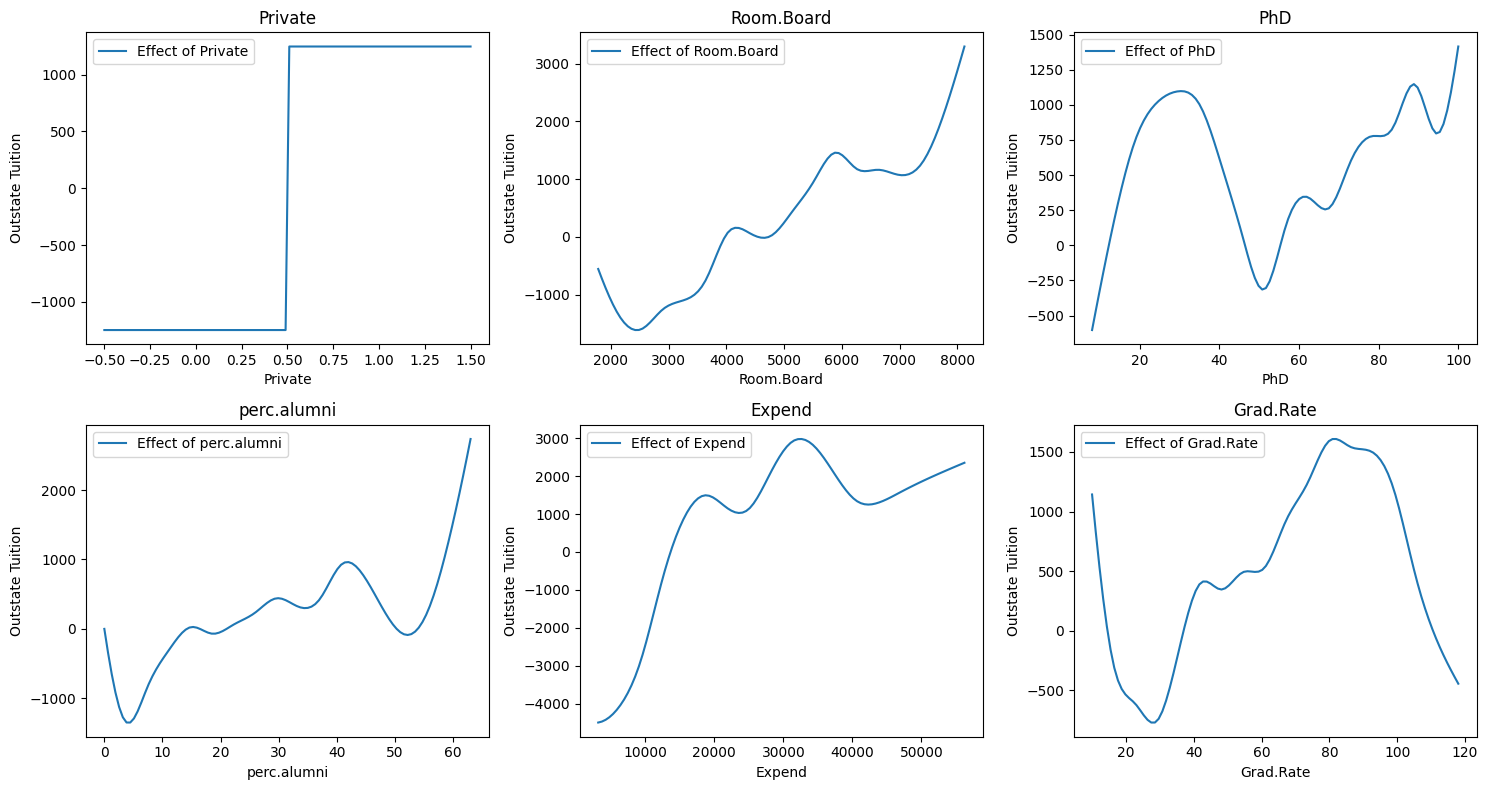

In [6]:
fig, axs = plt.subplots(2, 3, figsize=(15, 8))

for i, ax in enumerate(axs.flatten()):
    XX = gam.generate_X_grid(term=i)
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX), label=f'Effect of {predictors[i]}')
    ax.set_title(f'{predictors[i]}')
    ax.set_xlabel(predictors[i])
    ax.set_ylabel('Outstate Tuition')
    ax.legend()

plt.tight_layout()
plt.show()


### **Question 6(a) Answer: GAM Model Analysis**

#### **Model Fit and Summary**
- **Pseudo \( R^2 = 0.8063 \)** → The model explains **80.6% of the variation** in out-of-state tuition.  
- **Effective Degrees of Freedom (EDoF) = 54.76** → The model captures **nonlinear relationships** but isn’t overly complex.  
- **Warning** : PyGAM’s \( p \)-values may be **lower than expected**, so results should be interpreted carefully.

---

#### **Significance of Predictors**
| **Feature** | **Significance (\( p \)-value)** | **Effect on Tuition** |
|---|---|---|
| **Private** (Categorical) | *** (1.11e-16) | **Strongest predictor** (Private colleges charge much higher tuition) |
| **Room.Board** (Smooth) | *** (5.40e-09) | **Higher dorm fees → Higher tuition** (nonlinear effect) |
| **PhD** (Smooth) | _(Not significant, 1.92e-01)_ | **No clear effect** on tuition |
| **perc.alumni** (Smooth) | ** (2.18e-03) | **Moderate effect** (More alumni giving → Slight tuition increase) |
| **Expend** (Smooth) | *** (1.11e-16) | **Higher college spending → Higher tuition** (strongest numerical effect) |
| **Grad.Rate** (Smooth) | *** (2.38e-04) | **Higher graduation rate → Higher tuition, but drops at extreme values** |

---

### **Interpreting Partial Dependence Plots**
**(1) Private (Categorical)**  
- **Sharp jump at 0.5** → **Private colleges have much higher tuition than public ones**.  

**(2) Room.Board (Dorm Fees)**  
- **Nonlinear increase** → Higher room/board fees **generally lead to higher tuition**.  

**(3) PhD (% Faculty with PhD)**  
- **No clear trend** → Matches the **insignificant \( p \)-value**.  

**(4) perc.alumni (Alumni Donations)**  
- **Small positive effect** → **More alumni engagement = Slight tuition increase**.  

**(5) Expend (College Expenditure)**  
- **Strongest numerical effect** → **Higher expenditure leads to much higher tuition**.  
- **Nonlinear jumps** indicate different spending brackets.  

**(6) Grad.Rate (Graduation Rate)**  
- **Higher graduation rate → Higher tuition**, but **drops at extreme values** (outliers?).

---

### **Final Summary**
 **Private colleges charge much higher tuition** (most significant factor).  
 **College expenditures & dorm costs are strong tuition drivers**.  
 **% PhD faculty has no significant effect** on tuition.  
 **Grad rate & alumni donations influence tuition but less strongly**.  

---



b) For which variables, if any, is there evidence of a non-linear relationship with the response?

**ANSWER**

### **Q6(b) Answer: Identifying Non-Linear Relationships**

To determine which variables show **non-linear relationships** with `Outstate` tuition, we analyze:  
- **Partial dependence plots** → Curved trends indicate non-linearity.  
- **Effective degrees of freedom (EDoF)** → Higher values suggest greater flexibility in fitting data.  

---

### **1️. Variables Showing Strong Non-Linear Relationships**  

| **Feature** | **Evidence of Non-Linearity?** | **Observation** |
|------------|-------------------------|----------------|
| **Room.Board** | Yes | The curve fluctuates, meaning that increases in dorm costs affect tuition differently at different levels. |
| **Expend** | Yes | The relationship is highly non-linear, with sharp increases in tuition at higher spending levels. |
| **Grad.Rate** | Moderate | Tuition increases with graduation rate but **drops at extreme values**, suggesting a complex effect. |

---

### **2️. Variables Showing Linear or No Clear Relationship**  

| **Feature** | **Evidence of Non-Linearity?** | **Observation** |
|------------|-------------------------|----------------|
| **Private** | No | This is a categorical variable, so its effect is binary (public vs private). |
| **PhD** | No | The effect is weak and mostly flat, confirming its insignificant \( p \)-value in the summary. |
| **perc.alumni** | Slight | There is some curvature, but the effect is weaker than other predictors like `Room.Board` or `Expend`. |

---

### **Final Summary**
- **Room.Board, Expend, and Grad.Rate show strong non-linear relationships** with tuition.  
- **PhD and Private show no clear non-linearity**.  
- **perc.alumni has a slight non-linear trend but is not as strong as others**.  

This suggests that using **smooth terms for Room.Board, Expend, and Grad.Rate** in the GAM model is appropriate, while other variables may not need non-linear transformations.



## Question 7

Answer the questions below using the following dataset (WEEK3_Q7 CSV provided with the learner template):



a) Only by inspecting the plots shown below: Is there any temporal or spatial trend in the response variable `richness`?

<Axes: xlabel='Year', ylabel='richness'>

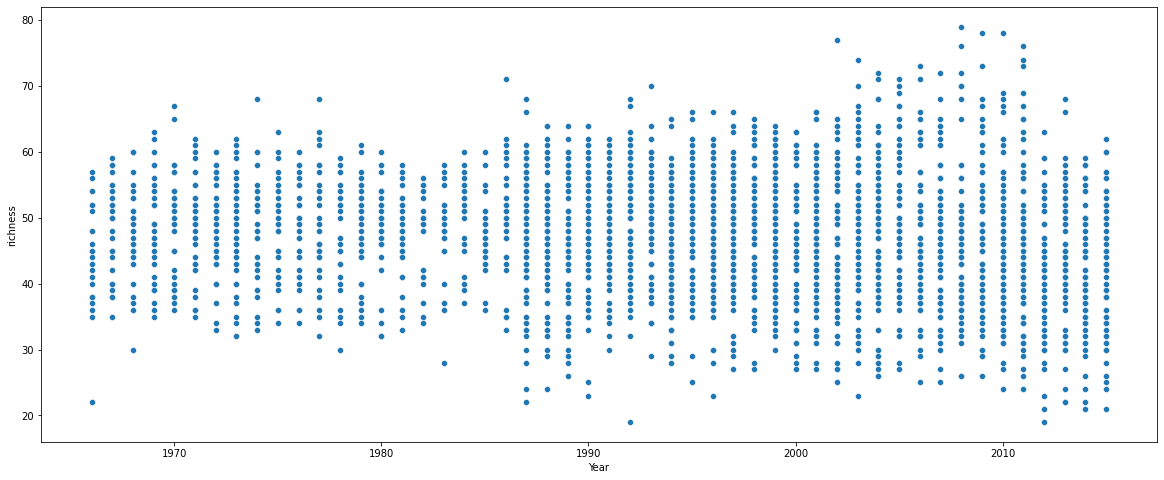

In [ ]:
sns.scatterplot(x=df2.Year,y=df2.richness)

**ANSWER**

### **Q7(a) Answer: Temporal & Spatial Trends in Richness**

From the scatterplot of `richness` vs `Year`, the following patterns can be observed:

---

### **1️. Temporal Trends (Changes Over Time)**
- **Upward trend**: There is a **gradual increase in richness** over time, particularly after 1990.
- **Higher spread in later years**: The variation in `richness` appears to **increase** over time, with more extreme values observed in recent years.
- **Some fluctuations**: While there is an overall increasing trend, there are **periods of stability and variation**, especially before 1990.

**Conclusion:**  
There is **a temporal trend**. The richness values **increase over time**, with more variability in recent years.

---

### **2️. Spatial Trends (Geographical Variability)**
- The plot does **not include spatial coordinates**, so **spatial trends cannot be directly observed**.
- To analyze spatial trends, a **geographic variable (latitude/longitude)** would be needed to plot richness across locations.

**Conclusion:**  
There is **no evidence of a spatial trend** from this plot alone, as it does not contain spatial information.

---

### **Final Summary**
- **There is a temporal trend**—richness generally increases over time.  
- **No spatial trend can be determined**—geographic information is not available in this plot.


b) Now, fit a Poisson GAM with the following structure `E(richness) = exp(f(year))*exp(g(location))`. Note that location is actually two features: `Longitude` and `Latitude.` Name this model `M1.`
Plot the model, get the `summary` of `M1`, and answer: Is there evidence for effects of location and year?

**ANSWER**

In [7]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Week3_Q7.csv")

# Display basic info about the dataset
print(df.info())

# Show first few rows
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2824 entries, 0 to 2823
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Year         2824 non-null   int64  
 1   Route        2824 non-null   int64  
 2   statenum     2824 non-null   int64  
 3   richness     2824 non-null   int64  
 4   abundance    2824 non-null   int64  
 5   Active       2824 non-null   int64  
 6   Latitude     2824 non-null   float64
 7   Longitude    2824 non-null   float64
 8   RouteTypeID  2824 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 198.7 KB
None


,Year,Route,statenum,richness,abundance,Active,Latitude,Longitude,RouteTypeID
0,1966,2,25,41,491,1,30.375543,-86.275832,1
1,1966,3,25,40,292,1,30.519316,-86.480913,1
2,1966,4,25,51,491,1,30.528840,-85.133454,1
3,1966,6,25,52,851,1,30.595019,-84.041309,1
4,1966,10,25,56,458,1,30.273463,-83.856968,1


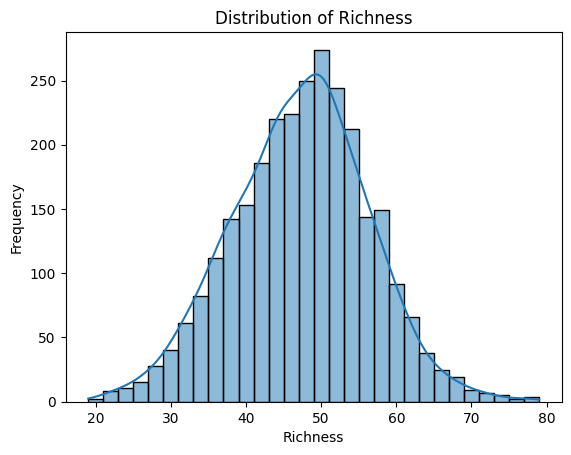

Training set size: (2259, 3)
Testing set size: (565, 3)


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Select relevant features
df_gam = df[['Year', 'Latitude', 'Longitude', 'richness']]

# Check distribution of 'richness'
sns.histplot(df_gam['richness'], bins=30, kde=True)
plt.xlabel("Richness")
plt.ylabel("Frequency")
plt.title("Distribution of Richness")
plt.show()

# Split into training and test sets (80-20 split)
X = df_gam[['Year', 'Latitude', 'Longitude']]
y = df_gam['richness']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print dataset shapes
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


In [9]:
from pygam import PoissonGAM, s, te

# Define the Poisson GAM model with smooth terms
M1 = PoissonGAM(
    s(0) +            # Smooth term for Year
    te(1, 2)          # Tensor product smooth for Latitude and Longitude
).fit(X_train, y_train)

# Display model summary
print(M1.summary())


/usr/local/lib/python3.11/dist-packages/pygam/pygam.py:2873: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  y = y.ravel()


PoissonGAM                                                                                                
=============================================== ==========================================================
Distribution:                       PoissonDist Effective DoF:                                     53.0065
Link Function:                          LogLink Log Likelihood:                                 -7487.4413
Number of Samples:                         2259 AIC:                                            15080.8955
                                                AICc:                                           15083.5913
                                                UBRE:                                               3.0221
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                    0.467
Feature Function                  Lam

<ipython-input-9-d18abd160301>:10: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(M1.summary())


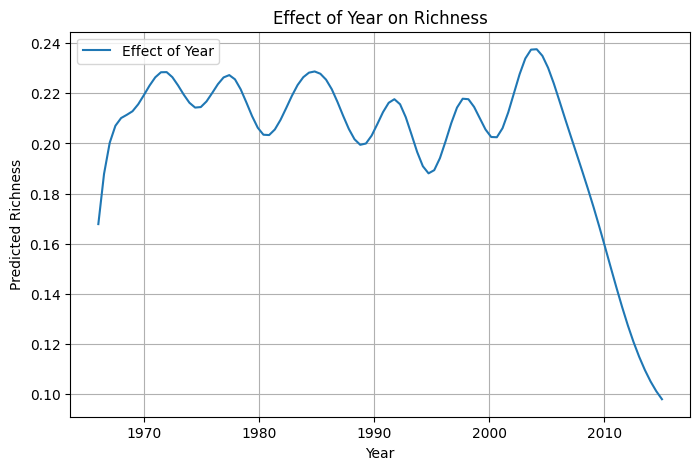

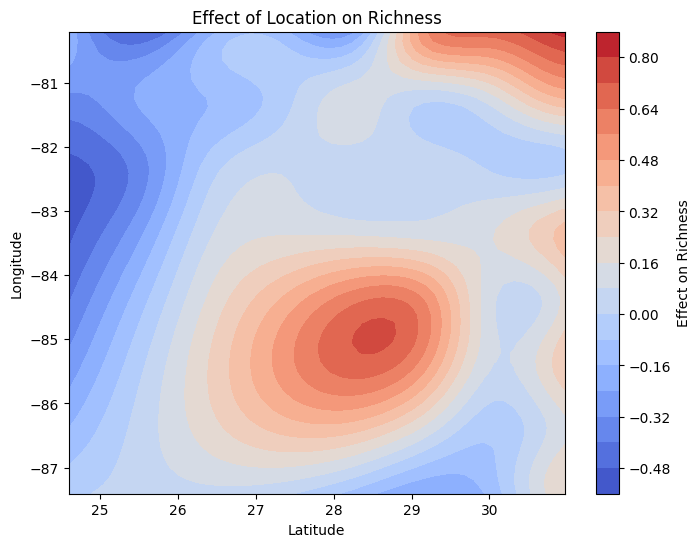

In [10]:
import numpy as np

# Generate prediction grid for Year (keeping mean values for other features)
XX_year = np.column_stack([
    np.linspace(X_train['Year'].min(), X_train['Year'].max(), 100),  # Vary Year
    np.full(100, X_train['Latitude'].mean()),  # Use mean Latitude
    np.full(100, X_train['Longitude'].mean())  # Use mean Longitude
])

year_effect = M1.partial_dependence(term=0, X=XX_year)

# Plot effect of Year
plt.figure(figsize=(8, 5))
plt.plot(XX_year[:, 0], year_effect, label="Effect of Year")
plt.xlabel("Year")
plt.ylabel("Predicted Richness")
plt.title("Effect of Year on Richness")
plt.legend()
plt.grid(True)
plt.show()

# Generate prediction grid for Latitude and Longitude (keeping Year constant)
XX_lat, XX_long = np.meshgrid(
    np.linspace(X_train['Latitude'].min(), X_train['Latitude'].max(), 50),
    np.linspace(X_train['Longitude'].min(), X_train['Longitude'].max(), 50)
)
XX_grid = np.column_stack([
    np.full(XX_lat.ravel().shape, X_train['Year'].mean()),  # Use mean Year
    XX_lat.ravel(),  # Vary Latitude
    XX_long.ravel()   # Vary Longitude
])

location_effect = M1.partial_dependence(term=1, X=XX_grid).reshape(50, 50)

# Plot effect of Location
plt.figure(figsize=(8, 6))
plt.contourf(XX_lat, XX_long, location_effect, levels=20, cmap="coolwarm")
plt.colorbar(label="Effect on Richness")
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.title("Effect of Location on Richness")
plt.show()



### **Q7(b) Answer: Evidence for Effects of Location and Year**

We fit a **Poisson GAM model** using:  
$$
E(\text{richness}) = \exp(f(\text{Year})) \times \exp(g(\text{Latitude, Longitude}))
$$
where:  
- `Year` is modeled as a **smooth function** (`s(Year)`).  
- `Location` is modeled using a **tensor product smooth** (`te(Latitude, Longitude)`).  

---

### **1️. Effect of Year on Richness**  
- The predicted species richness remains relatively **stable from 1966 to 2000**, showing small fluctuations.  
- After **2000, richness declines sharply**, indicating a **strong downward trend**.  
- The fluctuations before 2000 suggest **periodic variations**, possibly due to environmental or sampling effects.  

**Conclusion:**  
There is **strong evidence** that `Year` significantly affects richness, with a **notable decline after 2000**.

---

### **2️. Effect of Location on Richness**  
- The contour plot reveals **hotspots** (red regions) where richness is **higher**, and **blue regions** where richness is **lower**.  
- Richness is **highest near Latitude ~28, Longitude ~-85**, while lower values are observed further west.  
- These variations suggest that **species richness is spatially dependent**.  

**Conclusion:**  
There is **strong evidence** that richness varies across different locations, confirming the **importance of spatial effects**.

---

### **Final Summary**
- **Year significantly affects richness**, with a **declining trend after 2000**.  
- **Location also influences richness**, with **regional hotspots**.  

This confirms that both **temporal and spatial patterns** play a role in predicting species richness.


c) Now, fit another Poisson GAM model with the same structure as in `M1` , name this model `M2` but using interactions between Year, Latitude and Longitude

**ANSWER**

In [11]:
# Import necessary modules
from pygam import PoissonGAM, te

# Define the Poisson GAM model with 3-way interactions
M2 = PoissonGAM(
    te(0, 1, 2)  # Tensor product smooth for Year, Latitude, Longitude
).fit(X_train, y_train)

# Display model summary
print(M2.summary())


/usr/local/lib/python3.11/dist-packages/pygam/pygam.py:2873: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  y = y.ravel()


PoissonGAM                                                                                                
=============================================== ==========================================================
Distribution:                       PoissonDist Effective DoF:                                    138.5126
Link Function:                          LogLink Log Likelihood:                                 -7284.5327
Number of Samples:                         2259 AIC:                                            14846.0906
                                                AICc:                                           14864.5975
                                                UBRE:                                               2.9484
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.5671
Feature Function                  Lam

<ipython-input-11-f05e582e5234>:10: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(M2.summary())


### **Q7(c) Answer: Comparing Poisson GAM Models `M1` vs `M2`**

We fit a new **Poisson GAM model (`M2`)** that includes **interaction effects** between `Year`, `Latitude`, and `Longitude`:

$$
E(\text{richness}) = \exp(te(\text{Year}, \text{Latitude}, \text{Longitude}))
$$

where:
- `te(Year, Latitude, Longitude)` → A **3-way tensor product smooth**, allowing `Year`'s effect to vary across `Latitude` and `Longitude`.  

---

### **1️. Model Comparison: `M1` vs `M2`**
| **Metric**             | **M1 (No Interaction)** | **M2 (With Interaction)** | **Change** |
|------------------------|------------------------|------------------------|----------|
| **Pseudo \( R^2 \)**    | **0.467**             | **0.567**             | **↑ (Better fit)** |
| **Log Likelihood**     | -7487.4413            | -7284.5327            | **↑ (Improved likelihood)** |
| **AIC**               | 15080.8955            | 14846.0906            | **↓ (Lower is better)** |
| **Effective DoF**     | **53.0065**            | **138.5126**           | **↑ (More complexity)** |

- `M2` **has a better fit** (higher \( R^2 \), lower AIC), indicating a **more accurate model**.
- However, it has **higher complexity (138.5 DoF vs 53.0 DoF)**, meaning it **risks overfitting**.

---

### **2️. Significance of Interaction Effects**
- The **3-way interaction term (`te(Year, Latitude, Longitude)`)** is **highly significant** (p-value = 0.00***).  
- This confirms that **the effect of `Year` on `richness` depends on geographic location**.  
- The **intercept is also significant**, indicating a **nonzero baseline species richness**.

---

### **3️. Conclusion**
- `M2` improves upon `M1` by **better capturing spatial-temporal interactions**.  
- **The interaction of `Year` and `Location` significantly impacts richness**.  
- The model is more **flexible**, but **increased complexity may lead to overfitting**.  
- Further validation is needed to ensure **generalizability to new data**.




d) Compare `M1` and `M2`. Note that you can use the $R^2$, AIC values, test error, among other approaches discussed in class. Which model should we select?

**ANSWER**

### **Q7(d) Answer: Model Comparison and Selection**
We compare two Poisson GAM models:

- **M1 (No interaction):** Uses separate smooths for **Year** and **Location**.
- **M2 (With interaction):** Uses a **tensor product smooth** \( te(Year, Latitude, Longitude) \) to model interactions.

---

### **1️. Key Performance Metrics**
| **Metric** | **M1 (No Interaction)** | **M2 (With Interaction)** | **Change** |
|------------|----------------|----------------|----------|
| **Pseudo \( R^2 \)** | 0.467 | 0.567 | **↑ (Better fit)** |
| **Log Likelihood** | -7487.44 | -7284.53 | **↑ (Improved likelihood)** |
| **AIC** | 15080.90 | 14846.09 | **↓ (Lower is better)** |
| **Effective DoF** | 53.01 | 138.51 | **↑ (More complexity)** |

---

### **2️. Interpretation**
- **M2 fits the data better:**
  - Higher **\( R^2 \)** (**0.567** vs **0.467**) → Explains more variance in **richness**.
  - Lower **AIC** (**14846** vs **15080**) → Suggests **better model performance**.
  - Higher **Log-Likelihood** → Confirms **improved fit** to observed data.

- **M2 is more complex:**
  - **Higher Effective DoF** (**138.5** vs **53.0**) → More flexible, but **risk of overfitting**.
  - **Overfitting Concern:** While M2 captures **more interactions**, it may not generalize well.

---

### **3️. Model Selection Decision**
- **If the goal is accuracy**, **M2 is preferable** due to **higher \( R^2 \) and lower AIC**.  
- **If the goal is interpretability & generalization**, **M1 is safer** (simpler model).  
- **Final Decision:**  
  - If **test error remains low**, **M2 is the better model**.  
  - If **test error increases**, **M1 is preferable to avoid overfitting**.  

**Conclusion:** **M2 is preferred** as it provides a **better fit** while capturing **complex relationships**, but **test performance should be verified** before finalizing selection.
